In [ ]:
# Importing vector data by GD file ID. Thanks ChatGPT!
# Planicie con paleocauces NE-SW - https://drive.google.com/file/d/1FlXwNM-wLGYmKaXurD9rhPhSJxX9gNf9/view?usp=drive_link
!gdown --id 1FlXwNM-wLGYmKaXurD9rhPhSJxX9gNf9
# Arroceras disriminadas x año ini y fin - https://drive.google.com/file/d/1ZV9nCnBKNouPN5p-_FQJN98wBd0_nuwA/view?usp=sharing
!gdown --id 1ZV9nCnBKNouPN5p-_FQJN98wBd0_nuwA
# MODIS global fire data, 2002-2022 - https://drive.google.com/file/d/12df24MvKXViotTUCuTcP6G0b1pT2PkLK/view?usp=sharing # Enlace original: https://gwis.jrc.ec.europa.eu/apps/country.profile/downloads
!gdown --id 12df24MvKXViotTUCuTcP6G0b1pT2PkLK
# Planicie de paleocauces + buffer 5000 m - https://drive.google.com/file/d/1nHQ9HNz9pf-sYBKj0WPAmAf1v6cXkCX-/view?usp=sharing
!gdown --id 1nHQ9HNz9pf-sYBKj0WPAmAf1v6cXkCX-

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1FlXwNM-wLGYmKaXurD9rhPhSJxX9gNf9
To: /content/Planicie-con-paleocauces-NE-SW.zip
100% 42.8k/42.8k [00:00<00:00, 56.6MB/s]
/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1ZV9nCnBKNouPN5p-_FQJN98wBd0_nuwA
To: /content/ArrocerasBBSS_discriminadasIniYFin_Junio2024v03.zip
100% 443k/443k [00:00<00:00, 33.7MB/s]
/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use 

In [ ]:
!unzip Planicie-con-paleocauces-NE-SW.zip
!unzip ArrocerasBBSS_discriminadasIniYFin_Junio2024v03
!unzip MODISGlobalFire_clipped_PPPCyBuffer.zip
!unzip PPPaleoC_buffer5000m.zip

Archive:  Planicie-con-paleocauces-NE-SW.zip
  inflating: Planicie con paleocauces NE-SW.dbf  
  inflating: Planicie con paleocauces NE-SW.prj  
  inflating: Planicie con paleocauces NE-SW.shx  
 extracting: Planicie con paleocauces NE-SW.cpg  
  inflating: Planicie con paleocauces NE-SW.shp  
Archive:  ArrocerasBBSS_discriminadasIniYFin_Junio2024v03.zip
   creating: ArrocerasBBSS_discriminadasIni&Fin_Junio2024v03/
  inflating: ArrocerasBBSS_discriminadasIni&Fin_Junio2024v03/ArrocerasBBSS_discriminadasIni&Fin_Junio2024v02.cpg  
  inflating: ArrocerasBBSS_discriminadasIni&Fin_Junio2024v03/ArrocerasBBSS_discriminadasIni&Fin_Junio2024v02.dbf  
  inflating: ArrocerasBBSS_discriminadasIni&Fin_Junio2024v03/ArrocerasBBSS_discriminadasIni&Fin_Junio2024v02.prj  
  inflating: ArrocerasBBSS_discriminadasIni&Fin_Junio2024v03/ArrocerasBBSS_discriminadasIni&Fin_Junio2024v02.qmd  
  inflating: ArrocerasBBSS_discriminadasIni&Fin_Junio2024v03/ArrocerasBBSS_discriminadasIni&Fin_Junio2024v02.shp  
  infl

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Handling and processing of georreferenced data
import geopandas as gpd

import matplotlib.lines as mlines

In [ ]:
targetCRS_meters = "EPSG:6933"

In [ ]:
vectorArrocDisc = gpd.read_file('/content/ArrocerasBBSS_discriminadasIni&Fin_Junio2024v03/ArrocerasBBSS_discriminadasIni&Fin_Junio2024v02.shp').to_crs(targetCRS_meters)
vectorPpPc = gpd.read_file('/content/Planicie con paleocauces NE-SW.shp').to_crs(targetCRS_meters)

vectorArrocDisc['anio_ini'] = pd.to_datetime(vectorArrocDisc['Tabla Clas'], format='%Y')
vectorArrocDisc['anio_fin'] = pd.to_datetime(vectorArrocDisc['Tabla Cl_1'], format='%Y')
vectorArrocDisc = vectorArrocDisc.drop(columns=['Tabla Clas',	'Tabla Cl_1'])

In [ ]:
vectorPpPc

,Id,Ss_Geomorf,U_Geomorf,S_Geomorf,Area,geometry
0,0,None,Planicie con paleocauces NE-SW,Sistema Bajo de los Saladillos,"2205,63924984351","POLYGON ((-5791054.142 -3689700.896, -5790734...."


In [ ]:
vectorArrocDisc.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   DN_final    49 non-null     int64         
 1   Tabla Cl_2  49 non-null     int64         
 2   Supf_x_clu  49 non-null     float64       
 3   geometry    49 non-null     geometry      
 4   anio_ini    49 non-null     datetime64[ns]
 5   anio_fin    49 non-null     datetime64[ns]
dtypes: datetime64[ns](2), float64(1), geometry(1), int64(2)
memory usage: 2.4 KB


## Análisis mensual

In [ ]:
df_BA_PdePC = pd.DataFrame()

listYYMM = []
for yy in range(2001, 2023):
  for mm in range(1, 13):
    listYYMM.append(f'{yy}-{mm}')

df_BA_PdePC['date'] = np.array(listYYMM)

In [ ]:
df_BA_PdePC

,date
0,2002-1
1,2002-2
2,2002-3
3,2002-4
4,2002-5
...,...
247,2022-8
248,2022-9
249,2022-10
250,2022-11


In [ ]:
gpd.read_file('/content/MODISGlobalFire_clipped_PPPCyBuffer/2003.geojson').info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   _uid_       6 non-null      float64       
 1   id          6 non-null      float64       
 2   initialdat  6 non-null      datetime64[ms]
 3   finaldate   6 non-null      datetime64[ms]
 4   area_ha     6 non-null      float64       
 5   geometry    6 non-null      geometry      
dtypes: datetime64[ms](2), float64(3), geometry(1)
memory usage: 416.0 bytes


In [ ]:
listArrays_toFlatten_Arr = [np.full(12, np.nan)] # Primeros 12 meses sin datos

for year in range(2002, 2023): # Global Fire dataset no inclute el año 2001
  # BURNED AREA data processing
  BurnedArea_YY = gpd.read_file(f'/content/MODISGlobalFire_clipped_PPPCyBuffer/{year}.geojson').to_crs(targetCRS_meters)

  #BurnedArea_YY['area_km2_gpd'] = BurnedArea_YY.area/1e6 # No es necesario.
  # El area quemada coincide con el area del pixel calculada ~ 0.21 km2
  BurnedArea_YY['area_haTokm2'] = BurnedArea_YY['area_ha']/1e2
  BurnedArea_YY['ini_month'] = [d.month for d in list(BurnedArea_YY['initialdat'])]

  # ARROCERAS data processing
  vectorAAxAnio = vectorArrocDisc.copy()
  if year != 2022:
    vectorAAxAnio_undiss = vectorAAxAnio[(vectorAAxAnio['anio_ini'] <= f'{year}') & (vectorAAxAnio['anio_fin'] > f'{year}')]
  else:
    vectorAAxAnio_undiss = vectorAAxAnio[(vectorAAxAnio['anio_fin'] == f'{year}')]
    #vectorAAxAnio[(vectorAAxAnio['anio_fin'] == f'{year}')]
  vectorAAxAnio_diss = vectorAAxAnio_undiss.dissolve()

  # BURNED AREA CLIPPING BY ARROCERAS x YY
  clippedGdf = gpd.clip(BurnedArea_YY, vectorAAxAnio_diss)
  clippedGdf['area_haTokm2'] = clippedGdf.area/1e6 # Correcion area x clipping

  # append BA x MM
  listArrays_toFlatten_Arr.append(np.array([np.sum(clippedGdf[clippedGdf['ini_month']==m]['area_haTokm2'].values) for m in range(1, 13)]))

array_AreasQuemadasArr = np.array(listArrays_toFlatten_Arr).flatten()

In [ ]:
listArrays_toFlatten_PPPC = [np.full(12, np.nan)] # Primeros 12 meses sin datos

for year in range(2002, 2023): # Global Fire dataset no inclute el año 2001
  # BURNED AREA data processing
  BurnedArea_YY = gpd.read_file(f'/content/MODISGlobalFire_clipped_PPPCyBuffer/{year}.geojson').to_crs(targetCRS_meters)

  #BurnedArea_YY['area_km2_gpd'] = BurnedArea_YY.area/1e6 # No es necesario.
  # El area quemada coincide con el area del pixel calculada ~ 0.21 km2
  BurnedArea_YY['area_haTokm2'] = BurnedArea_YY['area_ha']/1e2
  BurnedArea_YY['ini_month'] = [d.month for d in list(BurnedArea_YY['initialdat'])]

  # BURNED AREA CLIPPING BY PPPC
  clippedGdf = gpd.clip(BurnedArea_YY, vectorPpPc)
  clippedGdf['area_haTokm2'] = clippedGdf.area/1e6 # Correcion area x clipping

  # append BA x MM
  listArrays_toFlatten_PPPC.append(np.array([np.sum(clippedGdf[clippedGdf['ini_month']==m]['area_haTokm2'].values) for m in range(1, 13)]))

array_AreasQuemadasPPPC = np.array(listArrays_toFlatten_PPPC).flatten()

In [ ]:
df_BA_PdePC['dateBA_PdePCArroc_km2'] = array_AreasQuemadasArr
df_BA_PdePC['dateBA_PdePC_km2'] = array_AreasQuemadasPPPC

In [ ]:
df_BA_PdePC

,date,dateBA_PdePCArroc_km2,dateBA_PdePC_km2
0,2001-1,NaN,NaN
1,2001-2,NaN,NaN
2,2001-3,NaN,NaN
3,2001-4,NaN,NaN
4,2001-5,NaN,NaN
...,...,...,...
259,2022-8,0.0,7.851136
260,2022-9,0.0,2.156938
261,2022-10,0.0,0.000000
262,2022-11,0.0,4.759956


<ipython-input-13-5ed3e6ac52da>:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_xticklabels(axs.get_xticklabels(), rotation=45, ha='right', fontsize=11)


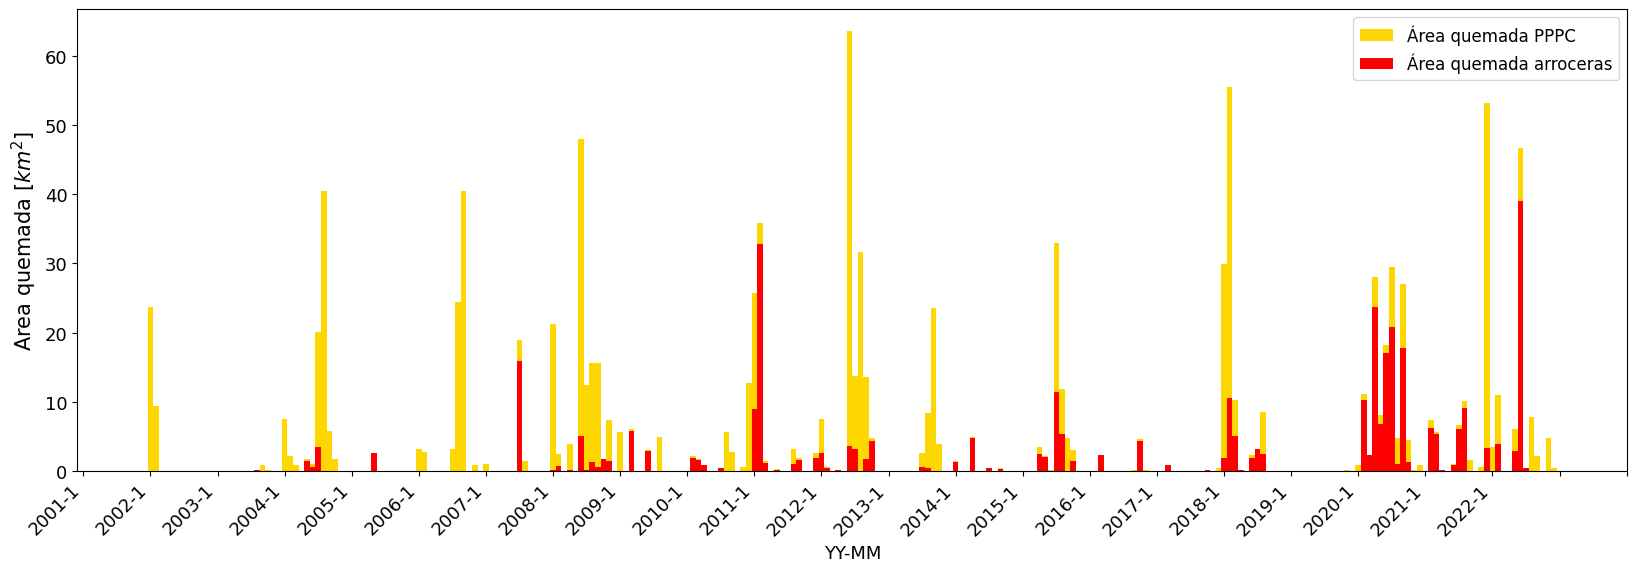

In [ ]:
# set up two subplots that share the x-axis to compare precipitation anomaly and ONI index
fig, axs = plt.subplots(figsize=(20, 6))

axs.bar(np.array(df_BA_PdePC['date']), array_AreasQuemadasPPPC,
        color='gold',
        width =1,
        label='Área quemada PPPC')

axs.bar(np.array(df_BA_PdePC['date']), array_AreasQuemadasArr,
        color='red',
        width =1,
        label='Área quemada arroceras')

axs.set_ylabel('Area quemada ['+r'$km^2$'+']', fontsize=15)
axs.set_xlabel('YY-MM', fontsize=13)
axs.legend(fontsize=12)

# Adjust the frequency of x-axis ticks
axs.xaxis.set_major_locator(plt.MultipleLocator(base=12))  # Adjust to desired frequency
axs.set_xticklabels(axs.get_xticklabels(), rotation=45, ha='right', fontsize=11)
axs.tick_params(axis='both', labelsize=13)

plt.show()

In [ ]:
from google.colab import files
df_BA_PdePC.to_csv('BA_PdePCyArroc_data.csv', encoding = 'utf-8-sig')
files.download('BA_PdePCyArroc_data.csv')

#dfHS_todownload.to_csv('AQ_2001_a_2022.csv', index=False)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
dfHS_todownload

,dates,AQ_PdePc_km2,AQ_Arroc_km2
0,2001-1,NaN,NaN
1,2001-2,NaN,NaN
2,2001-3,NaN,NaN
3,2001-4,NaN,NaN
4,2001-5,NaN,NaN
...,...,...,...
259,2022-8,7.851136,0.0
260,2022-9,2.156938,0.0
261,2022-10,0.000000,0.0
262,2022-11,4.759956,0.0


## Análisis anual

<ipython-input-25-c098f177063a>:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_xticklabels(axs.get_xticklabels(), rotation=45, ha='right', fontsize=18)


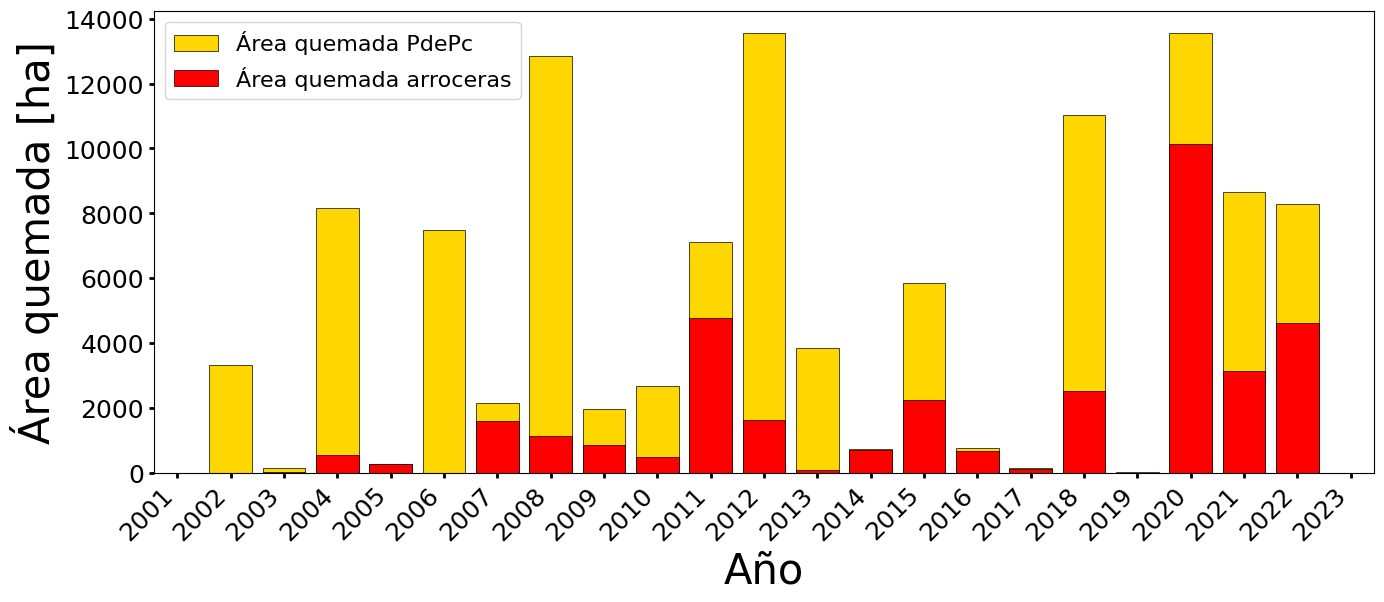

In [ ]:
# set up two subplots that share the x-axis to compare precipitation anomaly and ONI index
#fig, axs = plt.subplots(figsize=(20, 6))
fig, axs = plt.subplots(figsize=(40 / 2.54, 6))

axs.bar([yy for yy in range(2001, 2023)],
        np.array([np.sum(LA) for LA in listArrays_toFlatten_PPPC])*100,
        color='gold',
        width =0.8,
        label='Área quemada PdePc',
        edgecolor='black',  # Set the edge color to black
        linewidth=0.5)

axs.bar([yy for yy in range(2001, 2023)],
        np.array([np.sum(LA) for LA in listArrays_toFlatten_Arr])*100,
        color='red',
        width =0.8,
        label='Área quemada arroceras',
        edgecolor='black',  # Set the edge color to black
        linewidth=0.5)

#axs.set_ylabel('Area quemada ['+r'$km^2$'+']', fontsize=20)
axs.set_ylabel('Área quemada [ha]', fontsize=30)
axs.set_xlabel('Año', fontsize=30)
axs.legend(fontsize=16, loc='upper left')

# Adjust the frequency of x-axis ticks
axs.xaxis.set_major_locator(plt.MultipleLocator(base=1))  # Adjust to desired frequency
axs.set_xticklabels(axs.get_xticklabels(), rotation=45, ha='right', fontsize=18)
axs.tick_params(axis='both', labelsize=18, width=2)

plt.show()

In [ ]:
# prompt: download a plot and set dpi, set image length to view the x axis label
from google.colab import files

fig.savefig('my_plot.png', dpi=300, bbox_inches='tight')
files.download('my_plot.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Sin uso

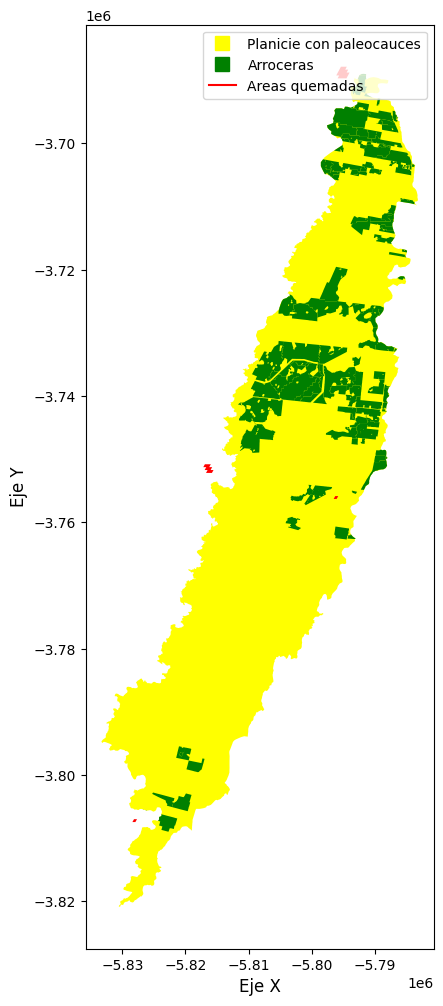

In [ ]:
targetCRS = "EPSG:4326"
BurnedArea_YY = gpd.read_file('/content/MODISGlobalFire_clipped_PPPCyBuffer/2019.geojson').to_crs(targetCRS_meters)

fig, axes = plt.subplots(figsize=(12, 12))

vectorPpPc.plot(ax=axes, color='yellow')
vectorArrocDisc.plot(ax=axes, color='green')
BurnedArea_YY.plot(ax=axes, color='red')

legVectorPcPCC = mlines.Line2D([], [], color = 'yellow', marker= 's', markersize=10, linestyle='none')
legvectorArrocDisc = mlines.Line2D([], [], color = 'green', marker= 's', markersize=10, linestyle='none')
legtestBurnedArea = mlines.Line2D([], [], color = 'red', marker = 'none', linestyle='-')
axes.legend(handles=[legVectorPcPCC, legvectorArrocDisc, legtestBurnedArea],
              labels=['Planicie con paleocauces', 'Arroceras', 'Areas quemadas'],
              fontsize = 10,
              loc='best')

axes.set_xlabel('Eje X', fontsize = 12)
axes.set_ylabel('Eje Y', fontsize = 12)

plt.show()